In [1]:
import sys
from pathlib import Path
HOME = Path(r"D:\Workspace\Repository\skripsi\object-detection-engine")
DATA = HOME / "data"
MODELS  = HOME / "models"
sys.path.append(str(MODELS))

In [2]:
import requests
from PIL import Image
import torch
import torchvision
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device 

device(type='cuda')

In [4]:
from transformers import Owlv2Processor, Owlv2ForObjectDetection

# Load the model and processor from the local directory
local_model_path = f"{MODELS}/owlv2"
processor = Owlv2Processor.from_pretrained(local_model_path)
model = Owlv2ForObjectDetection.from_pretrained(local_model_path).to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [5]:
help(processor.post_process_grounded_object_detection)

Help on method post_process_grounded_object_detection in module transformers.models.owlv2.processing_owlv2:

post_process_grounded_object_detection(outputs: 'Owlv2ObjectDetectionOutput', threshold: float = 0.1, target_sizes: Union[transformers.utils.generic.TensorType, list[tuple], NoneType] = None, text_labels: Optional[list[list[str]]] = None) method of transformers.models.owlv2.processing_owlv2.Owlv2Processor instance
    Converts the raw output of [`Owlv2ForObjectDetection`] into final bounding boxes in (top_left_x, top_left_y,
    bottom_right_x, bottom_right_y) format.

    Args:
        outputs ([`Owlv2ObjectDetectionOutput`]):
            Raw outputs of the model.
        threshold (`float`, *optional*, defaults to 0.1):
            Score threshold to keep object detection predictions.
        target_sizes (`torch.Tensor` or `list[tuple[int, int]]`, *optional*):
            Tensor of shape `(batch_size, 2)` or list of tuples (`tuple[int, int]`) containing the target size
      

In [6]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
texts = [["a photo of a cat", "a remote control"]]
inputs = processor(text=texts, images=image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

# Target image sizes (height, width) to rescale box predictions [batch_size, 2]
target_sizes = torch.Tensor([image.size[::-1]])
# Convert outputs (bounding boxes and class logits) to Pascal VOC Format (xmin, ymin, xmax, ymax)
results = processor.post_process_grounded_object_detection(
    outputs,
    target_sizes=[image.size[::-1]],
    threshold=0.4,
)
i = 0  
text = texts[i]
boxes, scores, labels = results[i]["boxes"], results[i]["scores"], results[i]["labels"]
for box, score, label in zip(boxes, scores, labels):
    box = [round(i, 2) for i in box.tolist()]
    print(f"Detected {text[label]} with confidence {round(score.item(), 3)} at location {box}")

Detected a remote control with confidence 0.805 at location [40.38, 73.28, 175.43, 117.49]
Detected a remote control with confidence 0.696 at location [334.95, 77.36, 366.9, 187.13]
Detected a photo of a cat with confidence 0.614 at location [341.67, 23.39, 642.32, 371.35]
Detected a photo of a cat with confidence 0.665 at location [6.75, 51.96, 326.62, 473.13]


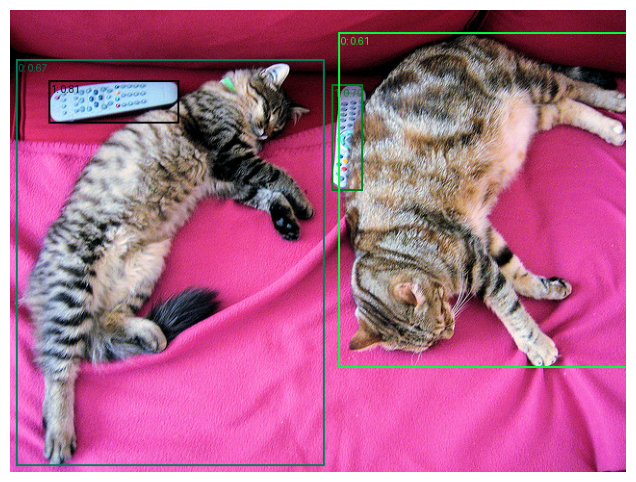

In [7]:
def plot_results(image, results):
    # Unpack results
    boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]

    # Convert image to tensor
    image_tensor = torchvision.transforms.functional.to_tensor(image) * 255
    image_tensor = image_tensor.to(torch.uint8)

    # Draw bounding boxes
    image_with_boxes = draw_bounding_boxes(
        image=image_tensor,
        boxes=boxes,
        labels=[f"{label}: {score.item():.2f}" for label, score in zip(labels, scores)],
        width=2
    )

    # Display image
    plt.figure(figsize=(8, 6))
    plt.imshow(image_with_boxes.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()

plot_results(image, results)

Detected a remote control with confidence 0.805 at location [40.38, 73.28, 175.43, 117.49]
Detected a remote control with confidence 0.696 at location [334.95, 77.36, 366.9, 187.13]
Detected a photo of a cat with confidence 0.614 at location [341.67, 23.39, 642.32, 371.35]
Detected a photo of a cat with confidence 0.665 at location [6.75, 51.96, 326.62, 473.13]


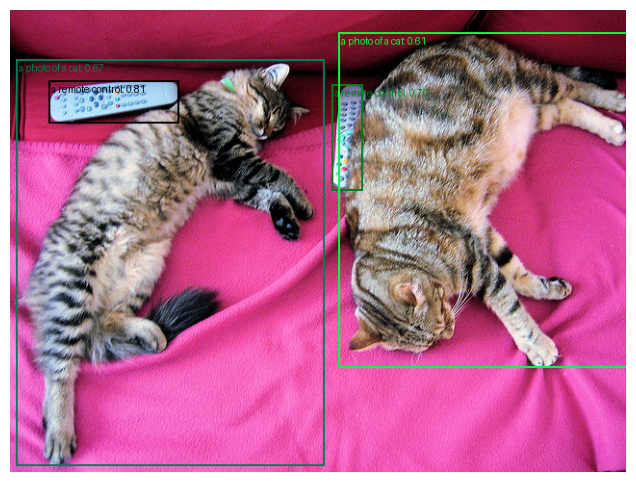

In [11]:
import onnxruntime as ort
from transformers import Owlv2Processor
from PIL import Image
import requests
import torch
import torchvision
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt

class ONNXOutput:
    def __init__(self, logits, pred_boxes):
        self.logits = logits
        self.pred_boxes = pred_boxes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if device.type == 'cuda' else ['CPUExecutionProvider']

onnx_model_path = f"{MODELS}/owlv2-onnx/model.onnx"
session = ort.InferenceSession(onnx_model_path, providers=providers)

local_model_path = f"{MODELS}/owlv2-onnx"
processor = Owlv2Processor.from_pretrained(local_model_path)

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)
texts = [["a photo of a cat", "a remote control"]]
inputs = processor(text=texts, images=image, return_tensors="pt")

onnx_inputs = {
    'pixel_values': inputs['pixel_values'].numpy(),
    'input_ids': inputs['input_ids'].numpy(),
    'attention_mask': inputs['attention_mask'].numpy()
}

outputs = session.run(None, onnx_inputs)

output_obj = ONNXOutput(
    logits=torch.from_numpy(outputs[0]),
    pred_boxes=torch.from_numpy(outputs[1])
)

results = processor.post_process_grounded_object_detection(
    output_obj,
    target_sizes=[image.size[::-1]],
    threshold=0.4,
)

i = 0
text = texts[i]
boxes, scores, labels = results[i]["boxes"], results[i]["scores"], results[i]["labels"]
for box, score, label in zip(boxes, scores, labels):
    box = [round(i, 2) for i in box.tolist()]
    print(f"Detected {text[label]} with confidence {round(score.item(), 3)} at location {box}")

def plot_results(image, results):
    boxes, scores, labels = results[0]["boxes"], results[0]["scores"], results[0]["labels"]
    image_tensor = torchvision.transforms.functional.to_tensor(image) * 255
    image_tensor = image_tensor.to(torch.uint8)
    image_with_boxes = draw_bounding_boxes(
        image=image_tensor,
        boxes=boxes,
        labels=[f"{text[label]}: {score.item():.2f}" for label, score in zip(labels, scores)],
        width=2
    )
    plt.figure(figsize=(8, 6))
    plt.imshow(image_with_boxes.permute(1, 2, 0).numpy())
    plt.axis("off")

plot_results(image, results)